
NPS PREDITIVO - TECH CHALLENGE FASE 1
=============================================================================
Case: Análise e predição do Net Promoter Score (NPS) em e-commerce
=============================================================================


Este documento tem por objetivo demonstrar as análises realizadas no projeto de NPS voltado para o e-commerce. <br>

Pergunta central : quais fatores operacionais realmente influenciam a satisfação do cliente e como a empresa pode agir de forma proativa para melhorar a experiência antes mesmo da aplicação da pesquisa de NPS?

Perguntas complementares : <br>
- Quais fatores parecem mais críticos para a satisfação? <br>
- O que mais gera detratores? <br>
- Existe algum “ponto de ruptura” na experiência do cliente? <br>
- Que tipo de cliente tende a ter NPS mais alto ou mais baixo? <br>


## **1) Bibliotecas**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             classification_report, confusion_matrix, accuracy_score)
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

import os
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")


## **2) Análise exploratória dos dados (EDA)**

### 2.1) Importando dados

In [4]:
df = pd.read_csv('desafio_nps_fase_1.csv')

In [5]:

colunas_pt = {
    'customer_id': 'id_cliente',
    'customer_age': 'idade_cliente',
    'customer_region': 'regiao_cliente',
    'customer_tenure_months': 'tempo_relacionamento_meses',
    'order_id': 'id_pedido',
    'order_value': 'valor_pedido',
    'items_quantity': 'qtd_itens',
    'discount_value': 'valor_desconto',
    'payment_installments': 'parcelas_pagamento',
    'delivery_time_days': 'tempo_entrega_dias',
    'delivery_delay_days': 'dias_atraso_entrega',
    'freight_value': 'valor_frete',
    'delivery_attempts': 'tentativas_entrega',
    'customer_service_contacts': 'contatos_atendimento',
    'resolution_time_days': 'tempo_resolucao_dias',
    'nps_score': 'nota_nps',
    'repeat_purchase_30d': 'recompra_30d',
    'complaints_count': 'qtd_reclamacoes',
    'csat_internal_score': 'csat_interno'
}
df.rename(columns=colunas_pt, inplace=True)

### 2.2) Tratamento de notas NPS <br><br>

As notas NPS possuem valores decimais (ex: 6.3, 7.8). Para categorizar
corretamente em Detrator/Neutro/Promotor, aplicamos arredondamento:
- \>= X.5 → arredonda para cima
- < X.5  → arredonda para baixo

Isso evita ambiguidade na classificação de notas como 6.5 ou 8.5.

In [6]:
print("=" * 80)
print("TRATAMENTO: ARREDONDAMENTO DAS NOTAS NPS")
print("=" * 80)

print(f"\nExemplos de notas originais (primeiros 10):")
print(df['nota_nps'].head(10).tolist())

df['nota_nps_original'] = df['nota_nps'].copy()
df['nota_nps_arredondada'] = df['nota_nps'].round(0).astype(int)

print(f"\nNotas após arredondamento:")
print(df['nota_nps_arredondada'].head(10).tolist())


TRATAMENTO: ARREDONDAMENTO DAS NOTAS NPS

Exemplos de notas originais (primeiros 10):
[6.9, 2.4, 4.8, 5.9, 6.1, 0.9, 1.4, 0.0, 6.2, 2.7]

Notas após arredondamento:
[7, 2, 5, 6, 6, 1, 1, 0, 6, 3]


Verificar impacto do arredondamento

In [7]:
mudaram = (df['nota_nps_arredondada'] != df['nota_nps']).sum()
print(f"\nRegistros com nota alterada pelo arredondamento: {mudaram} ({mudaram/len(df)*100:.1f}%)")


Registros com nota alterada pelo arredondamento: 2075 (83.0%)


Distribuição antes e depois

In [8]:
print(f"\nDistribuição das notas arredondadas:")
print(df['nota_nps_arredondada'].value_counts().sort_index())


Distribuição das notas arredondadas:
nota_nps_arredondada
0     213
1     133
2     277
3     300
4     392
5     328
6     358
7     206
8     145
9      82
10     66
Name: count, dtype: int64


### 2.3) Criação da variável Target: Classificação do NPS <BR>


Alinhado com a definição do grupo: a variável target é a CLASSIFICAÇÃO
do cliente (Detrator, Neutro ou Promotor), não a nota numérica.
- Detrator: notas 0 a 6
- Neutro: notas 7 e 8
- Promotor: notas 9 e 10

In [9]:
def classificar_nps(nota):
    if nota <= 6:
        return 'Detrator'
    elif nota <= 8:
        return 'Neutro'
    else:
        return 'Promotor'

df['categoria_nps'] = df['nota_nps_arredondada'].apply(classificar_nps)

### 2.4) Análises iniciais

#### Volumetria da base

In [10]:
print(f"\A base possui: {df.shape[0]} registros e {df.shape[1]} colunas")

\A base possui: 2500 registros e 22 colunas


#### Nulos

In [11]:
print(f"\nValores nulos por coluna:\n{df.isnull().sum()}")


Valores nulos por coluna:
id_cliente                    0
idade_cliente                 0
regiao_cliente                0
tempo_relacionamento_meses    0
id_pedido                     0
valor_pedido                  0
qtd_itens                     0
valor_desconto                0
parcelas_pagamento            0
tempo_entrega_dias            0
dias_atraso_entrega           0
valor_frete                   0
tentativas_entrega            0
contatos_atendimento          0
tempo_resolucao_dias          0
nota_nps                      0
recompra_30d                  0
qtd_reclamacoes               0
csat_interno                  0
nota_nps_original             0
nota_nps_arredondada          0
categoria_nps                 0
dtype: int64


#### Estatística descritiva

In [12]:
print(f"\nEstatísticas descritivas:\n{df.describe().round(2)}")


Estatísticas descritivas:
       id_cliente  idade_cliente  tempo_relacionamento_meses  id_pedido  \
count     2500.00        2500.00                     2500.00    2500.00   
mean      1250.50          43.40                       61.32   51250.50   
std        721.83          14.89                       34.48     721.83   
min          1.00          18.00                        1.00   50001.00   
25%        625.75          31.00                       31.00   50625.75   
50%       1250.50          43.00                       62.00   51250.50   
75%       1875.25          56.00                       91.00   51875.25   
max       2500.00          69.00                      119.00   52500.00   

       valor_pedido  qtd_itens  valor_desconto  parcelas_pagamento  \
count       2500.00    2500.00         2500.00             2500.00   
mean         434.26       3.47           29.75                6.00   
std          289.77       1.69           29.23                3.16   
min            7.

### 2.5) Distribuição do NPS

#### Histograma de notas

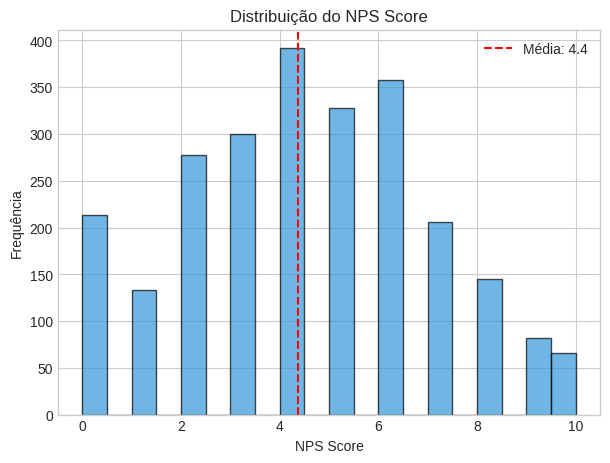

In [13]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.hist(df['nota_nps_arredondada'], bins=20, edgecolor='black', alpha=0.7, color='#3498db')
ax.set_xlabel('NPS Score')
ax.set_ylabel('Frequência')
ax.set_title('Distribuição do NPS Score')
ax.axvline(df['nota_nps_arredondada'].mean(), color='red', linestyle='--',
           label=f"Média: {df['nota_nps_arredondada'].mean():.1f}")
ax.legend()

#### Distribuição por categorias do NPS

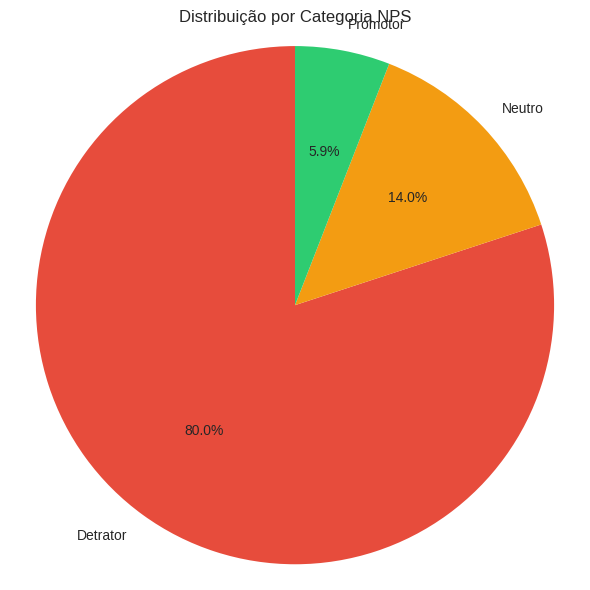

In [16]:
fig, ax = plt.subplots(figsize=(6, 6))

cat_counts = df['categoria_nps'].value_counts() \
    .reindex(['Detrator', 'Neutro', 'Promotor'], fill_value=0)

cores_nps = ['#e74c3c', '#f39c12', '#2ecc71']

ax.pie(
    cat_counts,
    labels=cat_counts.index,
    autopct='%1.1f%%',
    colors=cores_nps,
    startangle=90
)

ax.set_title('Distribuição por Categoria NPS')
ax.axis('equal')

plt.tight_layout()
plt.show()
plt.close()

In [17]:
nps_data = df['nota_nps_arredondada'].dropna()

media_nps = nps_data.mean()

print(f"\nDistribuição por categoria NPS:")
for cat, qtd in cat_counts.items():
    print(f"  {cat}: {qtd} ({qtd/len(df)*100:.1f}%)")
print(f"\nNota NPS média: {media_nps:.2f}")


Distribuição por categoria NPS:
  Detrator: 2001 (80.0%)
  Neutro: 351 (14.0%)
  Promotor: 148 (5.9%)

Nota NPS média: 4.38


### 2.6) Análises de correlação

#### Correlação entre variáveis numéricas e NPS


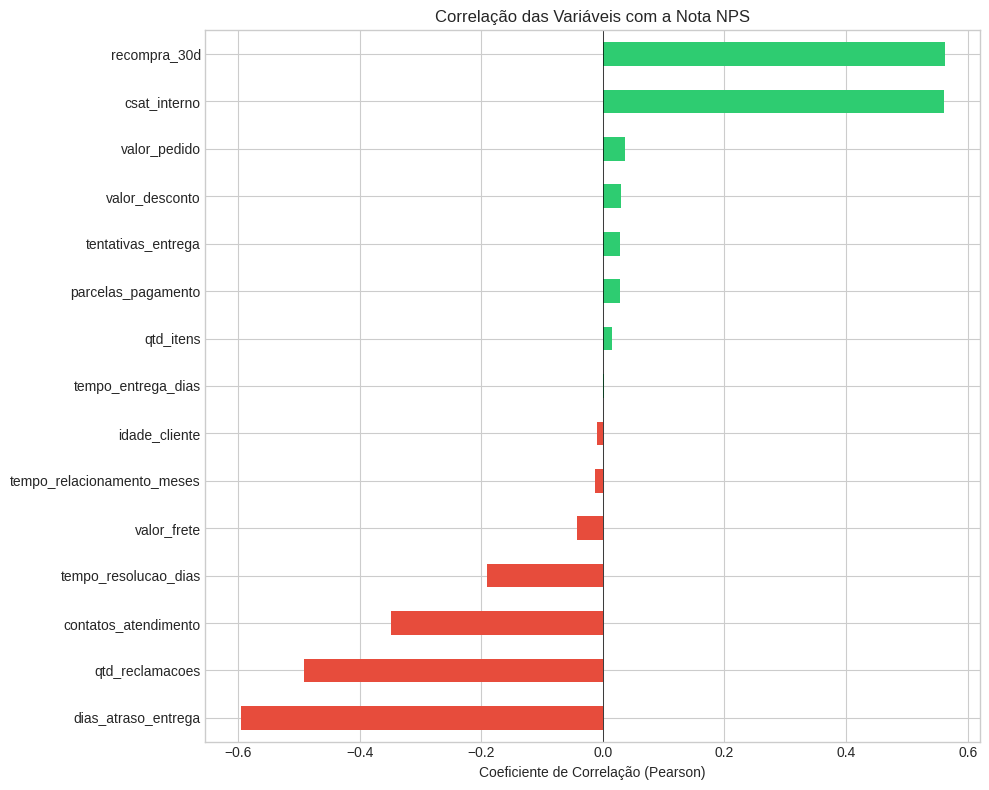

In [ ]:
colunas_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
for col in ['id_cliente', 'id_pedido']:
    colunas_numericas.remove(col)

correlacoes = df[colunas_numericas].corr()['nota_nps_arredondada'].drop(['nota_nps_arredondada','nota_nps_original','nota_nps']).sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
correlacoes.plot(kind='barh', ax=ax,
                 color=['#e74c3c' if x < 0 else '#2ecc71' for x in correlacoes])
ax.set_title('Correlação das Variáveis com a Nota NPS')
ax.set_xlabel('Coeficiente de Correlação (Pearson)')
ax.axvline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()
plt.close()

In [ ]:
print(f"\nCorrelação com a Nota NPS:")
print(correlacoes.round(3))


Correlação com a Nota NPS:
dias_atraso_entrega          -0.595
qtd_reclamacoes              -0.492
contatos_atendimento         -0.349
tempo_resolucao_dias         -0.191
valor_frete                  -0.042
tempo_relacionamento_meses   -0.013
idade_cliente                -0.009
tempo_entrega_dias            0.002
qtd_itens                     0.014
parcelas_pagamento            0.028
tentativas_entrega            0.029
valor_desconto                0.029
valor_pedido                  0.036
csat_interno                  0.562
recompra_30d                  0.562
Name: nota_nps_arredondada, dtype: float64


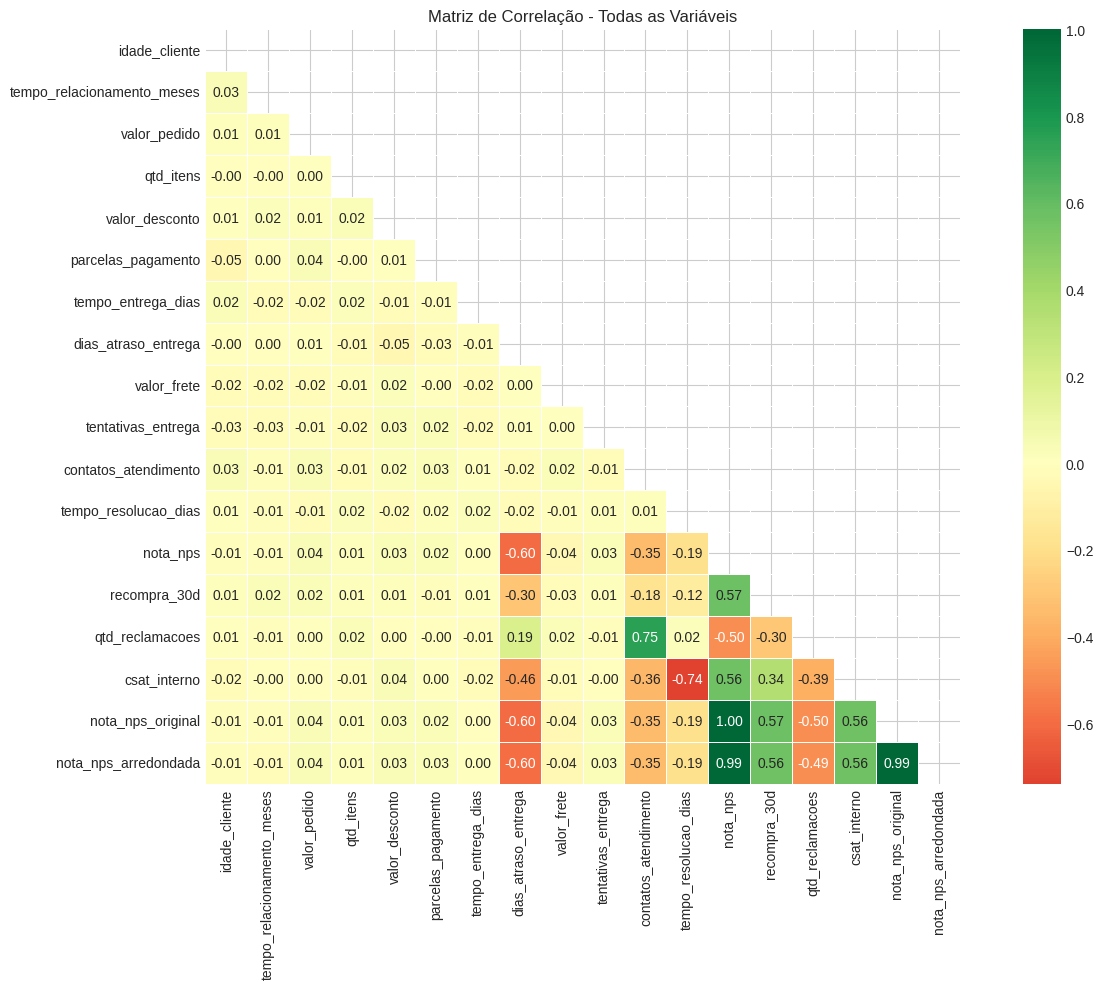

In [ ]:
fig, ax = plt.subplots(figsize=(14, 10))
corr_full = df[colunas_numericas].corr()
mask = np.triu(np.ones_like(corr_full, dtype=bool))
sns.heatmap(corr_full, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, square=True, linewidths=0.5)
ax.set_title('Matriz de Correlação - Todas as Variáveis')
plt.tight_layout()
plt.show()
plt.close()

Principais variáveis correlaciondas c/ NPS : <br><br>
- CORRELAÇÕES NEGATIVAS (DETRATORES) : <br>
1. Dias de atraso na entrega <br>
2. Quantidade de reclamações <br>
3. Quantidade de atendimentos do cliente <br>

- CORRELAÇÕES POSITIVAS (PROMOTORES) : <br>
1. Recompra nos próximos 30 dias <br>
2. CSAT <br>

#### Impacto do atraso da entrega

Text(0, 0.5, 'atraso')

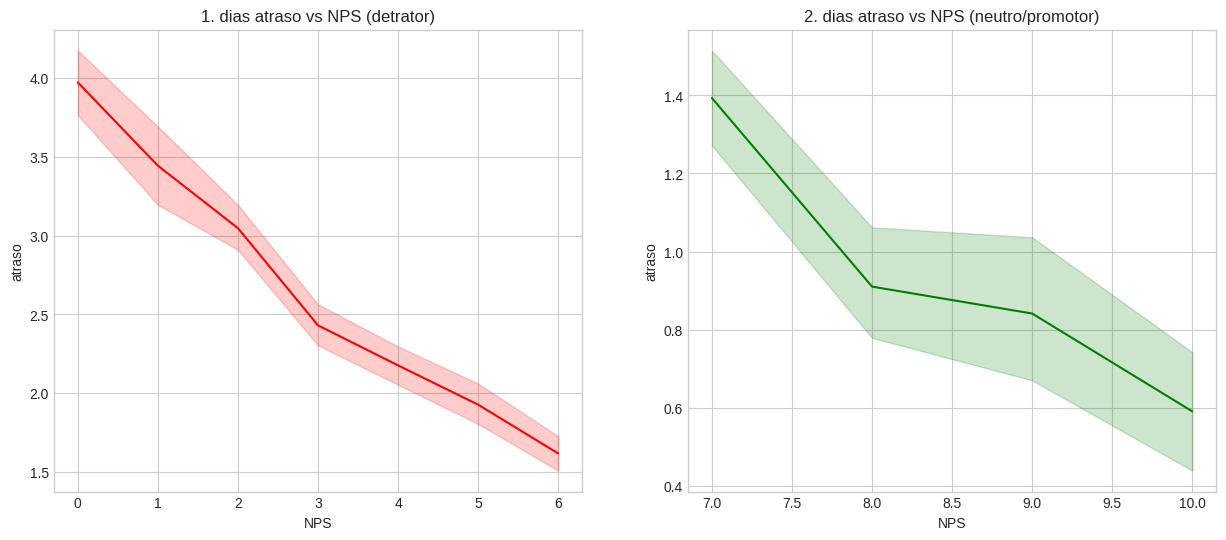

In [ ]:
fig, axes = plt.subplots(1,2, figsize=(15,6))
axes[0].grid(True)
axes[1].grid(True)


sns.lineplot(data=df[df['categoria_nps']=='Detrator'], x='nota_nps_arredondada', y='dias_atraso_entrega',ax=axes[0], color='red')
axes[0].set_title('1. dias atraso vs NPS (detrator)')
axes[0].set_xlabel('NPS')
axes[0].set_ylabel('atraso')

sns.lineplot(data=df[df['categoria_nps']!='Detrator'], x='nota_nps_arredondada', y='dias_atraso_entrega', ax=axes[1], color='green')
axes[1].set_title('2. dias atraso vs NPS (neutro/promotor)')
axes[1].set_xlabel('NPS')
axes[1].set_ylabel('atraso')

Gráfico 1 x Gráfico 2:

A variável de atraso na entrega divide muito bem os públicos.
CLientes detratores com notas menores que 4, possuem pelo menos 2 dias de atraso.

Enquanto as maiores notas estão concentradas nas entregas em dia ou até 1 dia de atraso.

#### Impacto do atendimento

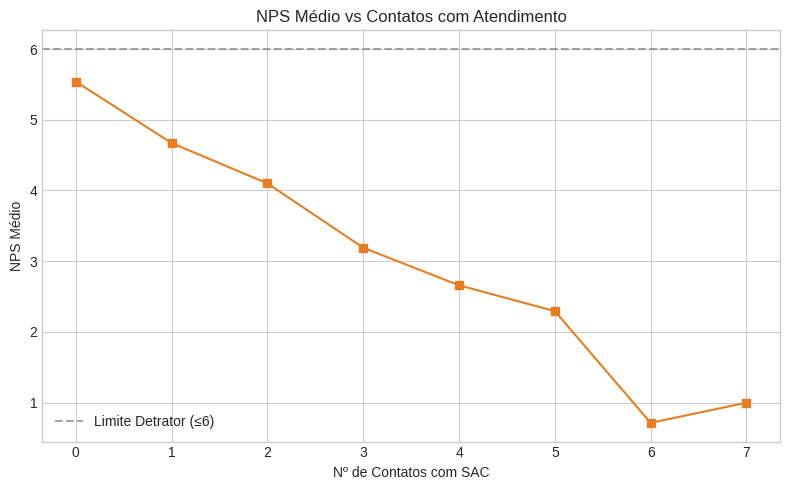

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

nps_contatos = (
    df.groupby('contatos_atendimento')['nota_nps_arredondada']
    .mean()
    .sort_index()
)

ax.plot(
    nps_contatos.index,
    nps_contatos.values,
    's-',
    color='#e67e22',
    markersize=6
)

ax.set_title('NPS Médio vs Contatos com Atendimento')
ax.set_xlabel('Nº de Contatos com SAC')
ax.set_ylabel('NPS Médio')

ax.axhline(
    y=6,
    color='gray',
    linestyle='--',
    alpha=0.7,
    label='Limite Detrator (≤6)'
)

ax.legend()

plt.tight_layout()
plt.show()
plt.close()

#### NPS médio por reclamação

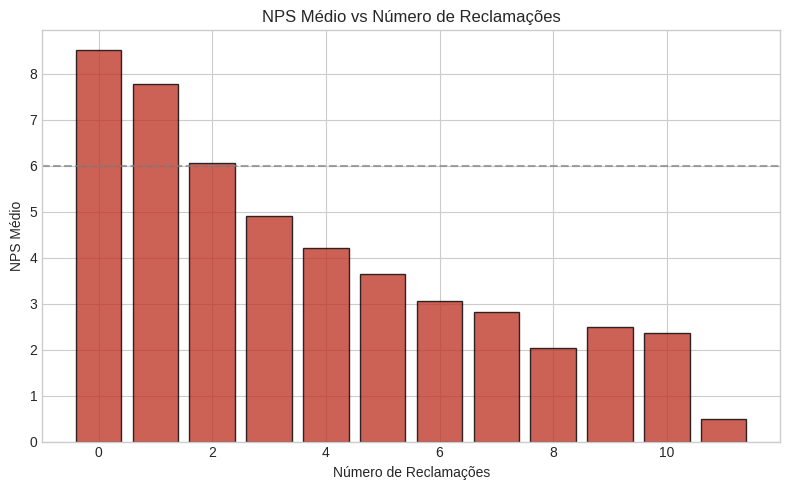

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

nps_reclamacoes = (
    df.groupby('qtd_reclamacoes')['nota_nps_arredondada']
    .mean()
    .sort_index()
)

ax.bar(
    nps_reclamacoes.index,
    nps_reclamacoes.values,
    color='#c0392b',
    edgecolor='black',
    alpha=0.8
)

ax.set_title('NPS Médio vs Número de Reclamações')
ax.set_xlabel('Número de Reclamações')
ax.set_ylabel('NPS Médio')

# Linha de referência
ax.axhline(y=6, color='gray', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()
plt.close()

Clientes com 2 ou mais reclamações são detratores.
É de suma importância que as áreas de ouvidoria se atentem para solucionar o problema do cliente antes da reclamação e no máximo na primeira reclamação.

#### NPS por recompra em 30 dias

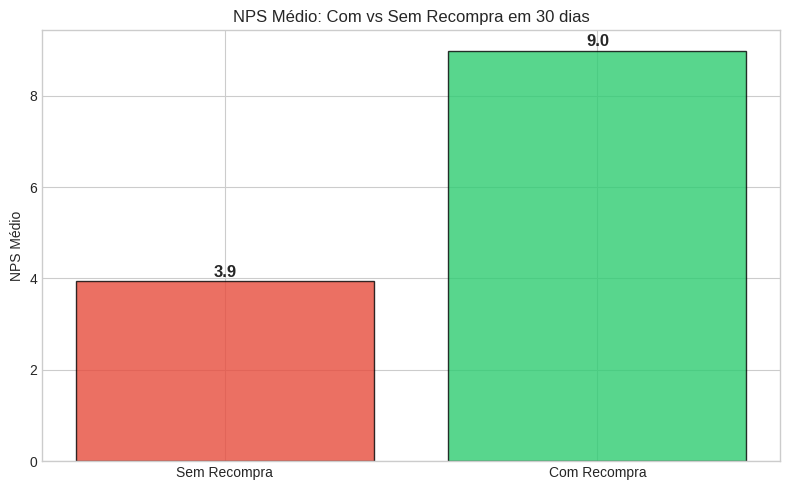

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

nps_recompra = df.groupby('recompra_30d')['nota_nps_arredondada'].mean()

labels = ['Sem Recompra', 'Com Recompra']

ax.bar(
    labels,
    nps_recompra.values,
    color=['#e74c3c', '#2ecc71'],
    edgecolor='black',
    alpha=0.8
)

ax.set_title('NPS Médio: Com vs Sem Recompra em 30 dias')
ax.set_ylabel('NPS Médio')

# Valores nas barras
for i, v in enumerate(nps_recompra.values):
    ax.text(i, v + 0.1, f'{v:.1f}', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()
plt.close()

Uma boa experiência fideliza o cliente. E o gráfico acima demonstra de forma clara, como clientes que recompram nos próximos 30 dias, são mais satisfeitos com sua experiência.

#### Comparação Detratores vs Promotores

In [ ]:
print("\n" + "-" * 60)
print("COMPARAÇÃO: DETRATORES vs PROMOTORES")
print("-" * 60)

detratores = df[df['categoria_nps'] == 'Detrator']
promotores = df[df['categoria_nps'] == 'Promotor']

cols_comparacao = [c for c in colunas_numericas if c != ['nota_nps_arredondada','nota_nps','nota_nps_original']]
comparacao = pd.DataFrame({
    'Detratores': detratores[cols_comparacao].mean(),
    'Promotores': promotores[cols_comparacao].mean(),
}).round(2)
comparacao['Diferença'] = (comparacao['Detratores'] - comparacao['Promotores']).round(2)
print(comparacao.sort_values('Diferença', ascending=False))


------------------------------------------------------------
COMPARAÇÃO: DETRATORES vs PROMOTORES
------------------------------------------------------------
                            Detratores  Promotores  Diferença
qtd_reclamacoes                   4.52        2.26       2.26
valor_frete                      38.35       36.52       1.83
tempo_resolucao_dias              5.73        3.95       1.78
dias_atraso_entrega               2.47        0.73       1.74
contatos_atendimento              1.66        0.70       0.96
tempo_entrega_dias                8.01        8.05      -0.04
tentativas_entrega                2.00        2.09      -0.09
parcelas_pagamento                5.98        6.12      -0.14
qtd_itens                         3.48        3.67      -0.19
idade_cliente                    43.40       43.79      -0.39
recompra_30d                      0.00        1.00      -1.00
valor_desconto                   29.51       31.22      -1.71
tempo_relacionamento_meses       6

#### Análise por boxplot

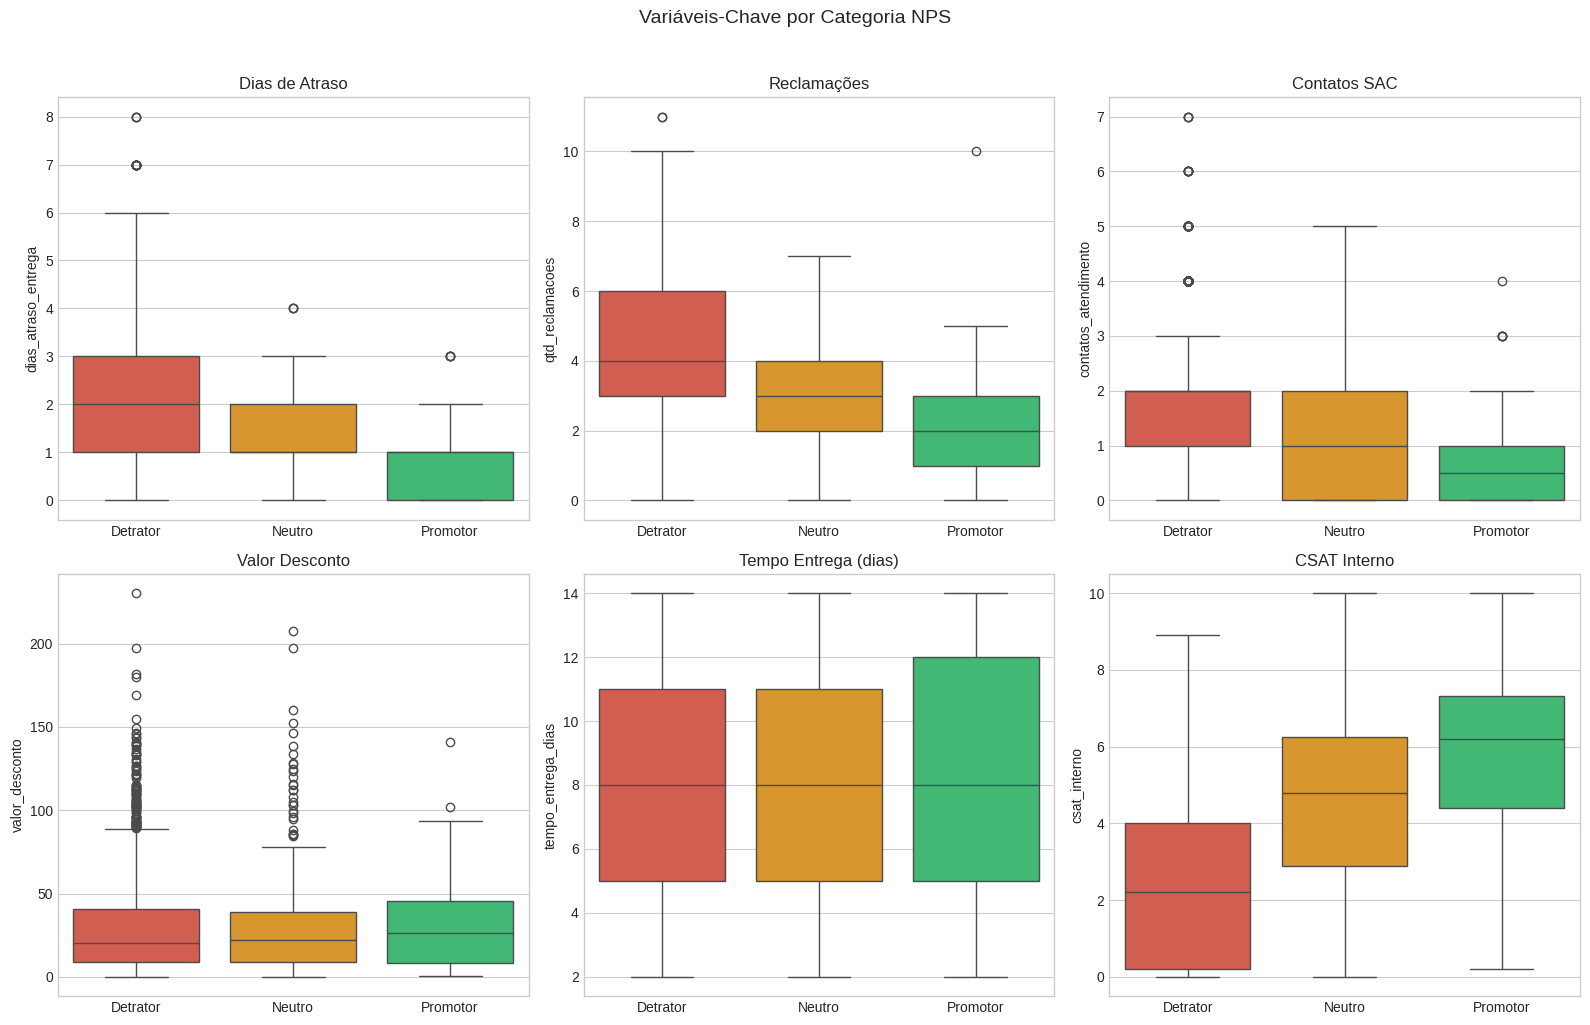

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
variaveis_chave = ['dias_atraso_entrega', 'qtd_reclamacoes', 'contatos_atendimento',
                   'valor_desconto', 'tempo_entrega_dias', 'csat_interno']
titulos = ['Dias de Atraso', 'Reclamações', 'Contatos SAC',
           'Valor Desconto', 'Tempo Entrega (dias)', 'CSAT Interno']

ordem_cat = ['Detrator', 'Neutro', 'Promotor']
for ax, var, titulo in zip(axes.flat, variaveis_chave, titulos):
    sns.boxplot(data=df, x='categoria_nps', y=var, order=ordem_cat, ax=ax,
                palette=['#e74c3c', '#f39c12', '#2ecc71'])
    ax.set_title(titulo)
    ax.set_xlabel('')

plt.suptitle('Variáveis-Chave por Categoria NPS', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()
plt.close()

**Principais highlights:** <br><br>

### 2.7) Análise de detratores com notas 0

In [ ]:
nota_zero = df[df['nota_nps_arredondada'] == 0]
demais = df[df['nota_nps_arredondada'] > 0]

print(f"\nClientes com nota 0: {len(nota_zero)} ({len(nota_zero)/len(df)*100:.1f}%)")
print(f"Clientes com nota > 0: {len(demais)} ({len(demais)/len(df)*100:.1f}%)")


Clientes com nota 0: 213 (8.5%)
Clientes com nota > 0: 2287 (91.5%)


#### Comparação de perfil: nota 0 vs demais

In [ ]:
cols_analise = ['dias_atraso_entrega', 'qtd_reclamacoes', 'contatos_atendimento',
                'tempo_resolucao_dias', 'valor_desconto', 'valor_pedido',
                'tempo_entrega_dias', 'valor_frete', 'recompra_30d', 'csat_interno']

comparacao_outlier = pd.DataFrame({
    'Nota 0': nota_zero[cols_analise].mean(),
    'Nota > 0': demais[cols_analise].mean(),
}).round(2)
comparacao_outlier['Diferença'] = (comparacao_outlier['Nota 0'] - comparacao_outlier['Nota > 0']).round(2)
print(f"\nPerfil comparativo - Nota 0 vs Demais:")
print(comparacao_outlier.sort_values('Diferença', ascending=False))


Perfil comparativo - Nota 0 vs Demais:
                      Nota 0  Nota > 0  Diferença
dias_atraso_entrega     3.97      2.02       1.95
qtd_reclamacoes         5.56      4.02       1.54
contatos_atendimento    2.52      1.43       1.09
valor_frete            39.13     38.13       1.00
tempo_resolucao_dias    6.35      5.41       0.94
recompra_30d            0.00      0.10      -0.10
tempo_entrega_dias      7.90      8.03      -0.13
valor_desconto         28.87     29.83      -0.96
csat_interno            0.81      3.14      -2.33
valor_pedido          412.92    436.25     -23.33


#### Correlação clientes nota 0 vs demais detratores (1-6)

In [ ]:
detratores_nao_zero = df[(df['nota_nps_arredondada'] >= 1) & (df['nota_nps_arredondada'] <= 6)]

print(f"\nCorrelação com NPS - Nota 0 vs Detratores (1-6):")
corr_zero = nota_zero[cols_analise + ['nota_nps_arredondada']].corr()['nota_nps_arredondada'].drop('nota_nps_arredondada')
corr_det = detratores_nao_zero[cols_analise + ['nota_nps_arredondada']].corr()['nota_nps_arredondada'].drop('nota_nps_arredondada')
comp_corr = pd.DataFrame({
    'Corr Nota=0': corr_zero,
    'Corr Detratores(1-6)': corr_det,
}).round(3)
print(comp_corr)


Correlação com NPS - Nota 0 vs Detratores (1-6):
                      Corr Nota=0  Corr Detratores(1-6)
dias_atraso_entrega           NaN                -0.418
qtd_reclamacoes               NaN                -0.275
contatos_atendimento          NaN                -0.198
tempo_resolucao_dias          NaN                -0.130
valor_desconto                NaN                 0.023
valor_pedido                  NaN                 0.008
tempo_entrega_dias            NaN                -0.014
valor_frete                   NaN                -0.031
recompra_30d                  NaN                   NaN
csat_interno                  NaN                 0.383


#### Perfil dos clientes nota 0

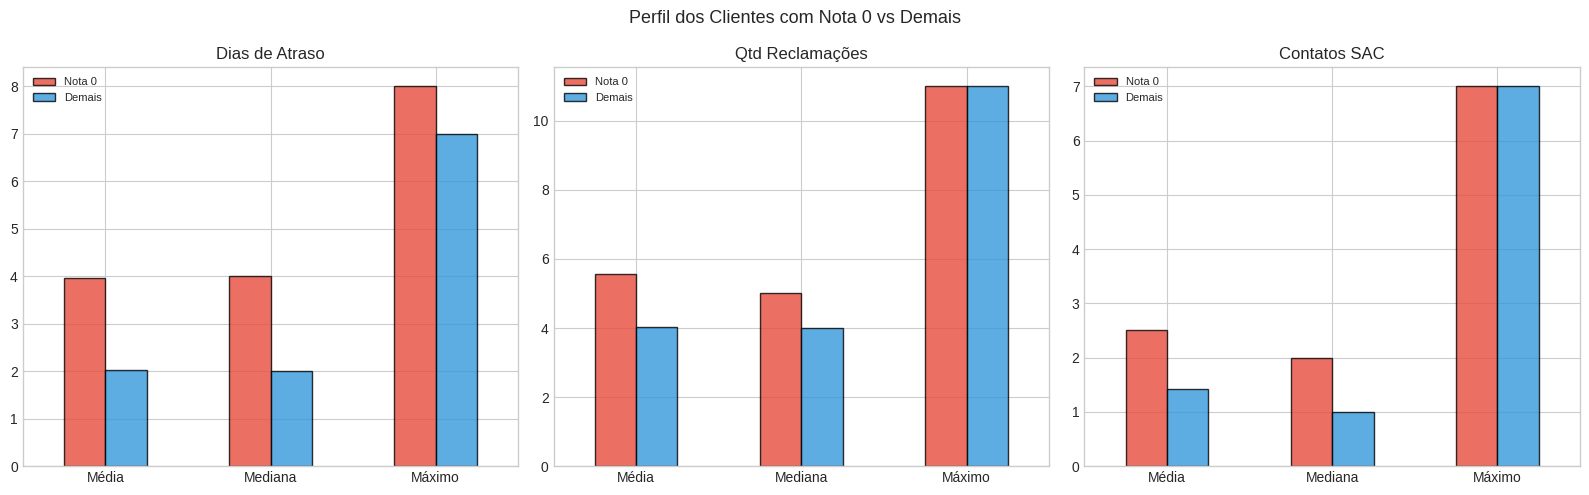

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

vars_destaque = ['dias_atraso_entrega', 'qtd_reclamacoes', 'contatos_atendimento']
titulos_destaque = ['Dias de Atraso', 'Qtd Reclamações', 'Contatos SAC']
for ax, var, titulo in zip(axes, vars_destaque, titulos_destaque):
    dados_plot = pd.DataFrame({
        'Nota 0': nota_zero[var].describe()[['mean', '50%', 'max']],
        'Demais': demais[var].describe()[['mean', '50%', 'max']],
    })
    dados_plot.index = ['Média', 'Mediana', 'Máximo']
    dados_plot.plot(kind='bar', ax=ax, color=['#e74c3c', '#3498db'],
                    edgecolor='black', alpha=0.8)
    ax.set_title(titulo)
    ax.tick_params(axis='x', rotation=0)
    ax.legend(fontsize=8)

plt.suptitle('Perfil dos Clientes com Nota 0 vs Demais', fontsize=13)
plt.tight_layout()
plt.show()
plt.close()

Clientes com nota 0 apresentam perfil extremo — atrasos maiores,mais reclamações e mais contatos com SAC. A correlação interna desse grupo é diferente dos demais detratores, indicando que são casos críticos que merecem tratamento diferenciado pela empresa.


### 2.8) Análise de Churn

A variável recompra_30d funciona como proxy inversa de churn:
- recompra_30d = 0 → cliente NÃO recomprou → possível churn
- recompra_30d = 1 → cliente recomprou → retido

In [ ]:
print("\n" + "=" * 80)
print("ANÁLISE DE CHURN (PROXY: RECOMPRA EM 30 DIAS)")
print("=" * 80)

df['risco_churn'] = (df['recompra_30d'] == 0).astype(int)

print(f"\nDistribuição de risco de churn:")
print(f"- Risco de churn (sem recompra): {df['risco_churn'].sum()} ({df['risco_churn'].mean()*100:.1f}%)")
print(f"- Retido (com recompra): {(df['risco_churn'] == 0).sum()} ({(1-df['risco_churn'].mean())*100:.1f}%)")



ANÁLISE DE CHURN (PROXY: RECOMPRA EM 30 DIAS)

Distribuição de risco de churn:
- Risco de churn (sem recompra): 2282 (91.3%)
- Retido (com recompra): 218 (8.7%)


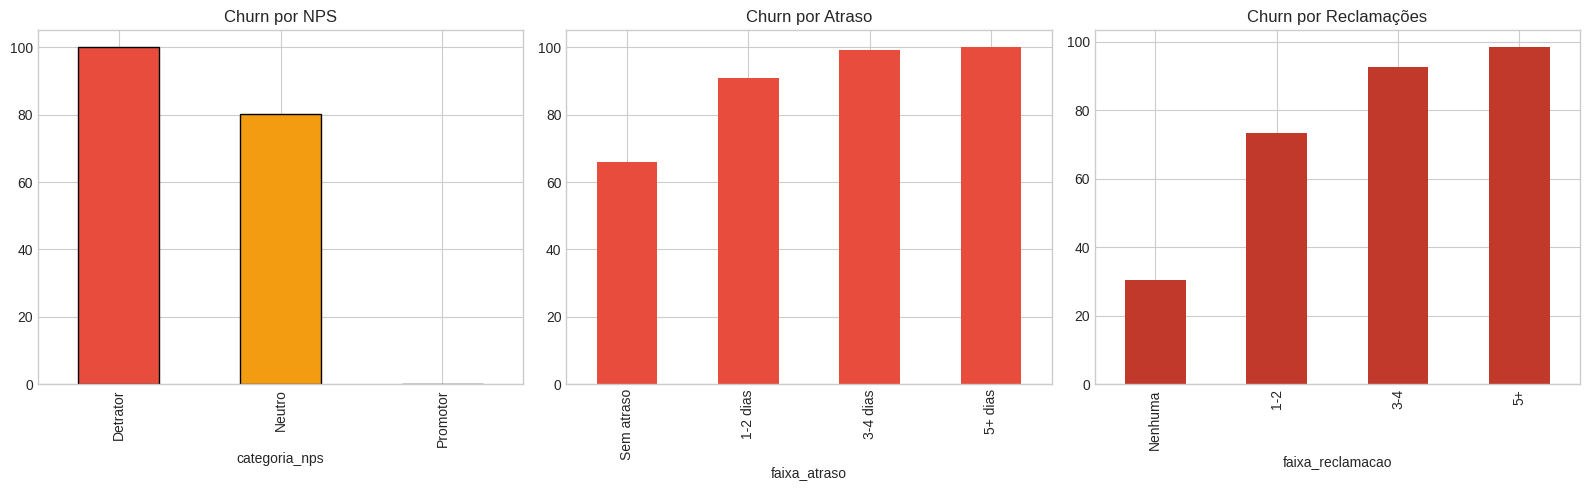

In [ ]:
# Definições necessárias
ordem_cat = ['Detrator', 'Neutro', 'Promotor']
cores_nps = ['#e74c3c', '#f39c12', '#2ecc71']

# Proxy churn
df['risco_churn'] = (df['recompra_30d'] == 0).astype(int)

# Churn por categoria
churn_por_cat = (
    df.groupby('categoria_nps')['risco_churn']
    .mean()
    .reindex(ordem_cat)
    * 100
)

# Faixas
df['faixa_atraso'] = pd.cut(
    df['dias_atraso_entrega'],
    bins=[-1, 0, 2, 4, float('inf')],
    labels=['Sem atraso', '1-2 dias', '3-4 dias', '5+ dias']
)

df['faixa_reclamacao'] = pd.cut(
    df['qtd_reclamacoes'],
    bins=[-1, 0, 2, 4, float('inf')],
    labels=['Nenhuma', '1-2', '3-4', '5+']
)

# Agrupamentos
churn_por_atraso = df.groupby('faixa_atraso', observed=True)['risco_churn'].mean() * 100
churn_por_reclamacao = df.groupby('faixa_reclamacao', observed=True)['risco_churn'].mean() * 100

# Plot
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# NPS
churn_por_cat.plot(kind='bar', ax=axes[0], color=cores_nps, edgecolor='black')
axes[0].set_title('Churn por NPS')

# Atraso
churn_por_atraso.plot(kind='bar', ax=axes[1], color='#e74c3c')
axes[1].set_title('Churn por Atraso')

# Reclamação
churn_por_reclamacao.plot(kind='bar', ax=axes[2], color='#c0392b')
axes[2].set_title('Churn por Reclamações')

plt.tight_layout()

plt.show()
plt.close()

In [ ]:
tabela_atraso = churn_por_atraso.reset_index()
tabela_atraso.columns = ['Faixa de Atraso', 'Churn (%)']

tabela_reclamacao = churn_por_reclamacao.reset_index()
tabela_reclamacao.columns = ['Faixa de Reclamações', 'Churn (%)']

print("\nChurn por Faixa de Atraso")
display(tabela_atraso.style.format({'Churn (%)': '{:.1f}%'}))

print("\nChurn por Faixa de Reclamações")
display(tabela_reclamacao.style.format({'Churn (%)': '{:.1f}%'}))


Churn por Faixa de Atraso


,Faixa de Atraso,Churn (%)
0,Sem atraso,66.1%
1,1-2 dias,90.7%
2,3-4 dias,99.1%
3,5+ dias,100.0%



Churn por Faixa de Reclamações


,Faixa de Reclamações,Churn (%)
0,Nenhuma,30.4%
1,1-2,73.4%
2,3-4,92.7%
3,5+,98.5%


### 2.9) Análises complementares

#### NPS por Região

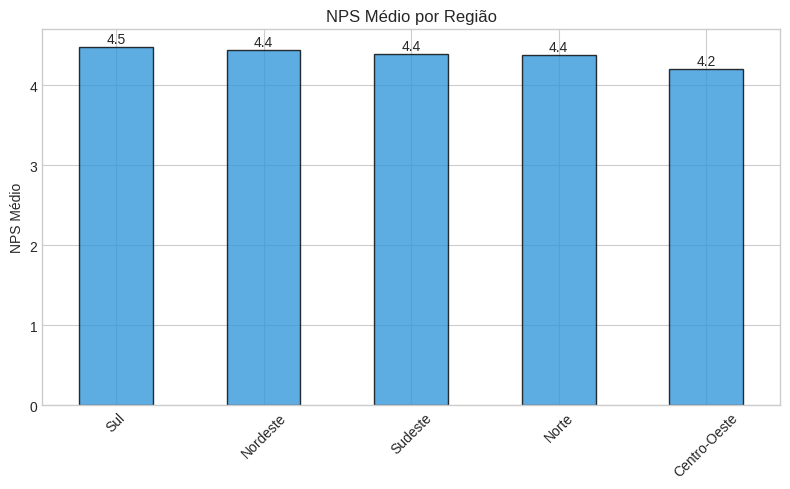

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

nps_regiao = (
    df.groupby('regiao_cliente')['nota_nps_arredondada']
    .agg(['mean', 'count'])
    .sort_values('mean', ascending=False)
)

nps_regiao['mean'].plot(
    kind='bar',
    ax=ax,
    color='#3498db',
    edgecolor='black',
    alpha=0.8
)

ax.set_title('NPS Médio por Região')
ax.set_ylabel('NPS Médio')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=45)

for i, v in enumerate(nps_regiao['mean']):
    ax.text(i, v + 0.05, f'{v:.1f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()
plt.close()

#### NPS por Faixa Etária

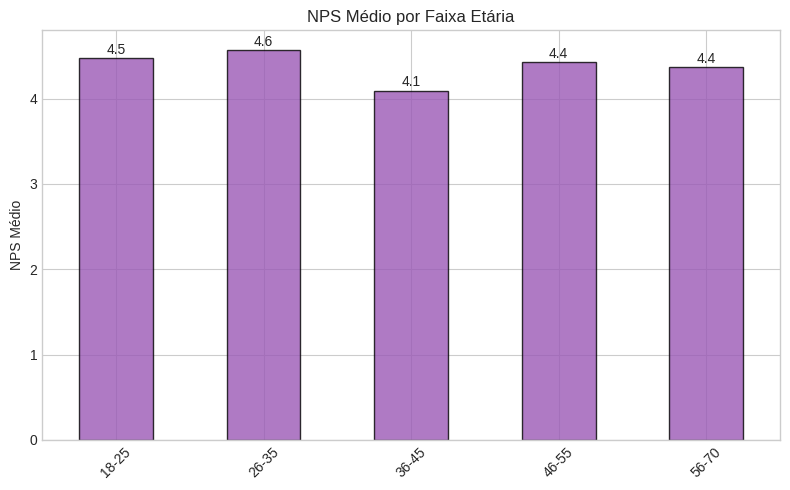

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

# Criar faixas etárias
df['faixa_etaria'] = pd.cut(
    df['idade_cliente'],
    bins=[17, 25, 35, 45, 55, 70],
    labels=['18-25', '26-35', '36-45', '46-55', '56-70'],
    include_lowest=True
)

nps_idade = (
    df.groupby('faixa_etaria', observed=True)['nota_nps_arredondada']
    .mean()
    .sort_index()
)

nps_idade.plot(
    kind='bar',
    ax=ax,
    color='#9b59b6',
    edgecolor='black',
    alpha=0.8
)

ax.set_title('NPS Médio por Faixa Etária')
ax.set_ylabel('NPS Médio')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=45)

# Valores nas barras
for i, v in enumerate(nps_idade):
    ax.text(i, v + 0.05, f'{v:.1f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()
plt.close()

In [ ]:
print(f"\nNPS por Região:\n{nps_regiao.round(2)}")
print(f"\nNPS por Faixa Etária:\n{nps_idade.round(2)}")


NPS por Região:
                mean  count
regiao_cliente             
Sul             4.47    521
Nordeste        4.44    485
Sudeste         4.38    520
Norte           4.38    506
Centro-Oeste    4.20    468

NPS por Faixa Etária:
faixa_etaria
18-25    4.47
26-35    4.57
36-45    4.09
46-55    4.43
56-70    4.37
Name: nota_nps_arredondada, dtype: float64


### 2.10) Conclusões EDA

#### Principais highlights (EDA)

FATORES MAIS CRÍTICOS PARA A SATISFAÇÃO:
1. Dias de atraso na entrega: correlação negativa mais forte com o NPS.
   Acima de 5 dias de atraso, o NPS médio cai drasticamente.
2. Quantidade de reclamações: segunda maior correlação negativa.
   Clientes com mais de 6 reclamações têm NPS próximo de zero.
3. Contatos com atendimento: múltiplos contatos indicam que o problema
   não foi resolvido na primeira interação.

Detratores com nota 0:
- Clientes com nota 0 possuem perfil extremo e diferente dos demais
  detratores. Apresentam atrasos maiores, mais reclamações e mais contatos
  com SAC. Merecem tratamento diferenciado como casos críticos.

CHURN:
- 100% dos detratores não recompraram em 30 dias (churn total)
- 100% dos promotores recompraram (retenção total)
- Atrasos e reclamações são os principais drivers de churn

#### Plano de ação p/ Business team

**ESTRATÉGIA ADOTADA:**
Modelo de classificação multiclasse (Detrator / Neutro / Promotor) utilizando
árvore de decisão. O objetivo não é acertar a nota exata do NPS, mas sim prever
a CATEGORIA do cliente antes do disparo da pesquisa.

TRATAMENTO DAS NOTAS:
As notas decimais foram arredondadas para inteiro antes da classificação,
evitando ambiguidade (ex: 6.5 → 7 = Neutro, 6.4 → 6 = Detrator).

ANÁLISE DE DETRATORES COM NOTA 0:
Clientes com nota 0 possuem perfil extremo e diferente dos demais detratores.
Recomenda-se tratamento diferenciado para esse grupo (ação imediata de
recuperação).

PLANO DE AÇÃO PARA REDUÇÃO DE CHURN:
1. AÇÃO IMEDIATA: Contato proativo com clientes preditos como Detratores
   dentro de 24h após a entrega (cupom de desconto, pedido de desculpas).
2. LOGÍSTICA: Reduzir atrasos de entrega para no máximo 3 dias. Conforme
   simulação, isso já melhora significativamente o NPS.
3. ATENDIMENTO: Resolver problemas no primeiro contato. Cada contato
   adicional com SAC reduz o NPS.
4. MONITORAMENTO: Clientes com mais de 3 reclamações devem ser sinalizados
   como "alto risco de churn" para ação preventiva.
5. RETROALIMENTAÇÃO: Compartilhar insights com TODOS os setores — a
   centralidade no cliente é responsabilidade de todos.

## 3) **Modelos de ML**

### 3.1) Criando ABT do modelo




Nossa variável target é classe_nps (promotor, neutro ou detrator).
portanto, inicialmente, vamos seguir com um modelo de classificação. <br> <br>

Ajustamos o texto de detrator, neutro e promotor e também colunamos as regiões para utilizarmos o algoritmo de árvore de decisão.

In [ ]:
nps_abt=df.copy()


nps_abt=pd.get_dummies(nps_abt, columns=['regiao_cliente'], drop_first=False)
nps_abt=nps_abt.drop(['faixa_etaria','faixa_atraso','faixa_reclamacao'], axis=1)

nps_abt.head()


,id_cliente,idade_cliente,tempo_relacionamento_meses,id_pedido,valor_pedido,qtd_itens,valor_desconto,parcelas_pagamento,tempo_entrega_dias,dias_atraso_entrega,...,csat_interno,nota_nps_original,nota_nps_arredondada,categoria_nps,risco_churn,regiao_cliente_Centro-Oeste,regiao_cliente_Nordeste,regiao_cliente_Norte,regiao_cliente_Sudeste,regiao_cliente_Sul
0,1,63,14,50001,139.73,4,39.35,4,2,2,...,6.5,6.9,7,Neutro,1,False,True,False,False,False
1,2,20,1,50002,458.95,2,9.51,10,6,4,...,0.0,2.4,2,Detrator,1,False,False,False,False,True
2,3,46,111,50003,507.06,5,42.82,6,6,1,...,1.5,4.8,5,Detrator,1,False,True,False,False,False
3,4,52,117,50004,302.19,2,19.58,9,5,2,...,0.3,5.9,6,Detrator,1,True,False,False,False,False
4,5,56,50,50005,253.06,1,29.37,11,13,1,...,7.9,6.1,6,Detrator,1,False,False,True,False,False


### 3.2) Feature e target


Separando as features e nossa target.
Importante removermos da feature a nota de nps, que resulta na classe do NPS.

In [ ]:
X = nps_abt.drop(['categoria_nps','nota_nps','nota_nps_original','nota_nps_arredondada'], axis=1) # features
y = nps_abt['categoria_nps']              # target

### 3.3) Treino e teste


Adotamos 80% para treinamento e 20% para teste.
Em seguida, avaliamos a proporção das classes em treino e teste.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split (
    X, y, test_size=0.2, random_state=42
)

### 3.4) Avaliando treino e teste

In [ ]:
y_test.value_counts(normalize=True) # avaliando a proporção de classe do teste

,proportion
categoria_nps,
Detrator,0.812
Neutro,0.136
Promotor,0.052


In [ ]:
y_train.value_counts(normalize=True) #avaliando a proporção de classe do treino

,proportion
categoria_nps,
Detrator,0.7975
Neutro,0.1415
Promotor,0.0610


### 3.5) Label encoder

Transformando nosso Y em 0,1,2 (detrator, neutro, promotor)
Para melhor compreensão do modelo.

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

### 3.6) Árvore de decisão


Aplicando modelo de árvore de decisão, com os seguintes parâmetros:
- Profundidade máxima de 5;
- Pelo menos 5 amostras em cada folha.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=5,
    random_state=42
)

model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, min_samples_leaf=5, random_state=42)

In [ ]:
y_pred = model.predict(X_test)

### 3.7) Avaliando resultados do modelo:

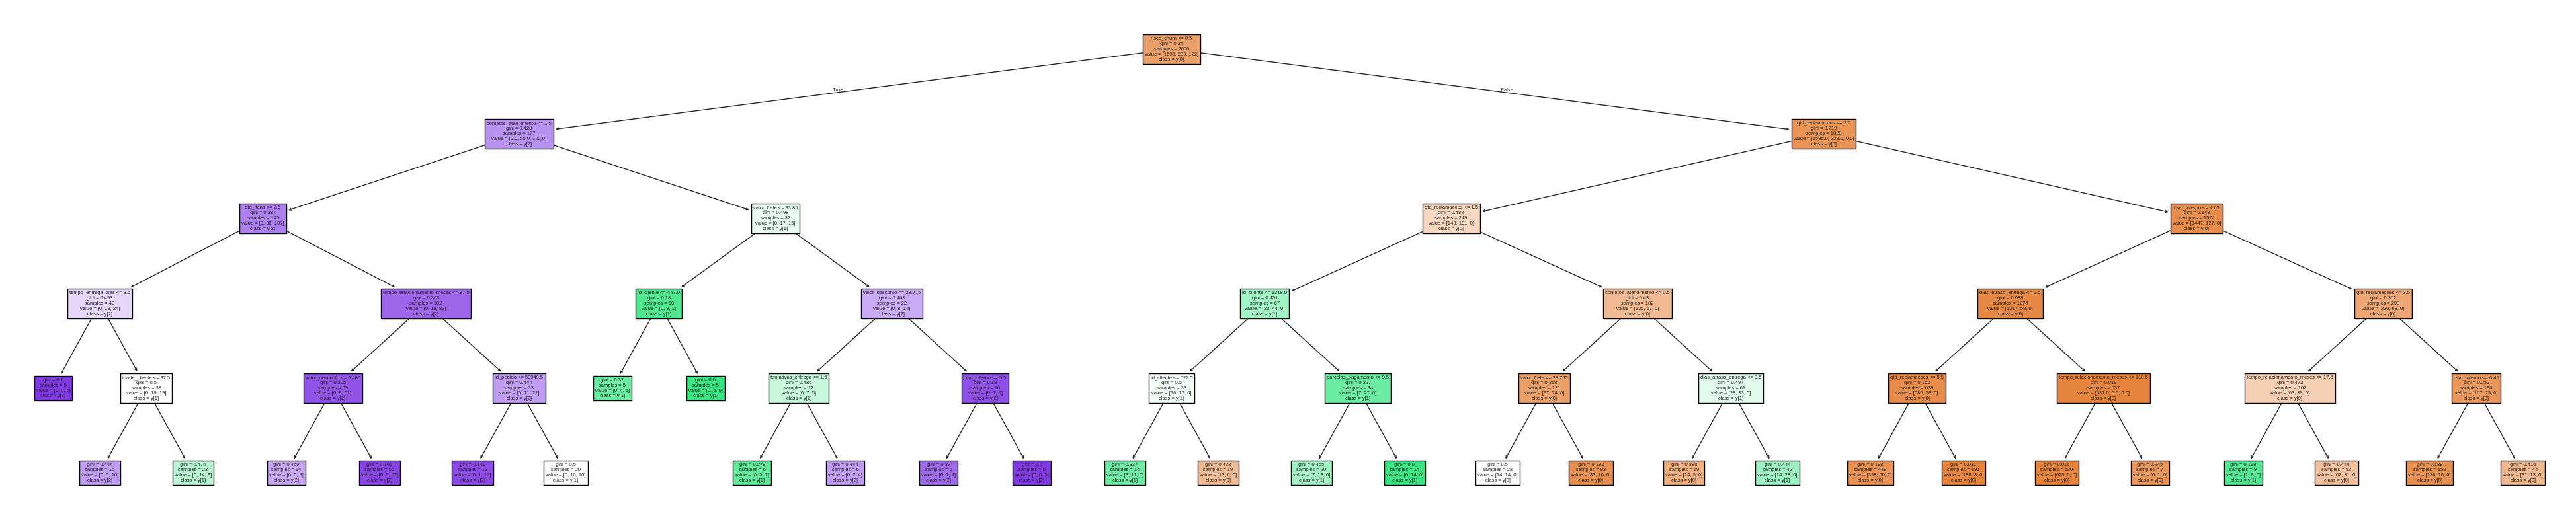

In [ ]:
from sklearn.tree import plot_tree
plt.figure(figsize=(50,10))
plot_tree(model, filled=True, feature_names=X.columns,class_names=True)
plt.show()

In [ ]:
model1 = DecisionTreeClassifier(
    max_depth=3,  # reduz profundidade
    random_state=42
)
model1.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [ ]:
from sklearn.tree import export_graphviz
import graphviz

dot_data = export_graphviz(
    model1,
    out_file=None,
    feature_names=X.columns,
    class_names=['Detrator', 'Neutro', 'Promotor'],
    filled=True,
    rounded=True,
    special_characters=True
)

graph = graphviz.Source(dot_data)
graph

graph.render("graph", format="png")

# baixa o arquivo certo
from google.colab import files
files.download("graph.png")




<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.856


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.97      0.94       406
           1       0.44      0.24      0.31        68
           2       0.61      0.65      0.63        26

    accuracy                           0.86       500
   macro avg       0.65      0.62      0.63       500
weighted avg       0.83      0.86      0.84       500



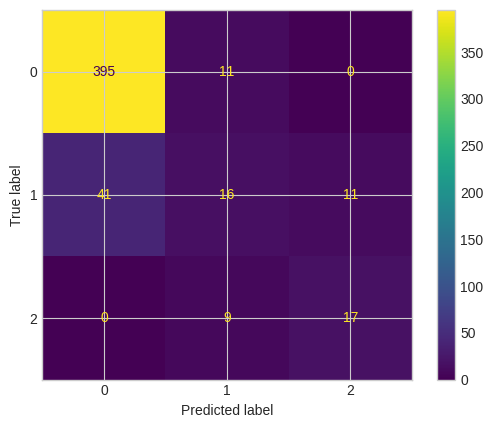

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

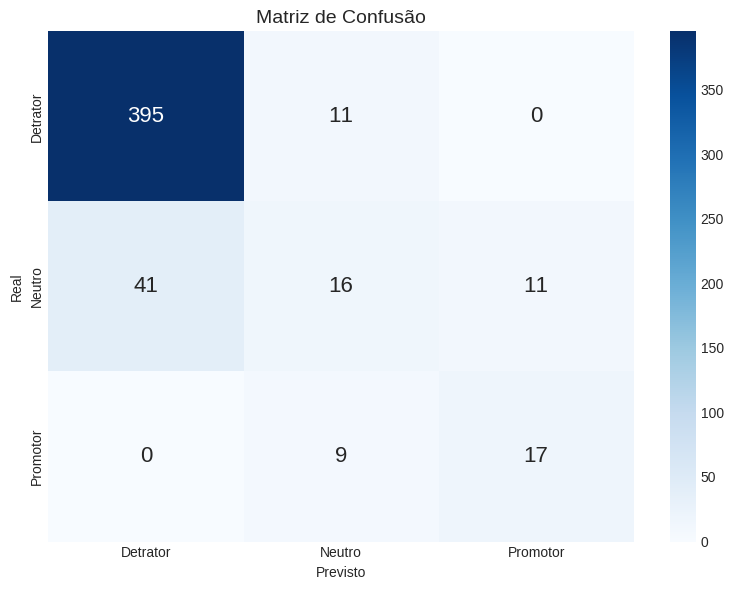

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# mapa de labels (ajustando os nomes)
labels_map = {
    0: 'Detrator',
    1: 'Neutro',
    2: 'Promotor'
}

# converter y verdadeiro e previsto
y_test_named = [labels_map[i] for i in y_test]
y_pred_named = [labels_map[i] for i in y_pred]

# ordem desejada
labels_order = ['Detrator', 'Neutro', 'Promotor']

# matriz de confusão
cm = confusion_matrix(y_test_named, y_pred_named, labels=labels_order)

# plot bonito
plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels_order,
    yticklabels=labels_order,
    annot_kws={'size' : 16}
)

plt.title('Matriz de Confusão', fontsize=14)
plt.xlabel('Previsto')
plt.ylabel('Real')

plt.tight_layout()
plt.show()



### 3.8) Conclusões - modelo preditivo

O modelo de árvore de decisão, identificou muito bem os detratores.
Para promotores, ele tem um bom acerto, mas confunde um pouco com os neutros.
Não identificamos nenhum promotor predito como detrator, o que é muito bom.
Porém para identificação de neutros, ele não atingiu as expectativas. A maioria dos casos ele acabou alocando como detrator.